# Findings 

- when an action leads to collide to the wall, it does nothing (stays in the same position before the action). 

- dot can be inside the wall, but it can't pass through the wall.  

- last state is discarded to match the action shape. 

- location[t+1] = location[t] + action[t]

- training model nevers sees `locations`, it's privileged ground truth. 

- the encoder gets intensities (pixel values) and must invert the rendering to recover the coordinate. If locations were literally embedded in the pixel values, decoding them would be a lookup, not representation learning.

In [67]:
from pathlib import Path 
import random
import sys
from pathlib import Path
import matplotlib.pyplot as plt 
import numpy as np
import torch
import yaml 

from eb_jepa.datasets.utils import init_data

REPO_ROOT = Path.cwd().parents[1]          # examples/my_ac_video_jepa -> repo root
sys.path.insert(0, str(REPO_ROOT))


# torch.manual_seed(0); np.random.seed(0); random.seed(0)

# `init_data`

In [68]:
CFG_PATH = Path.cwd().parent.parent / "cfgs" / "train.yaml"

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

cfg["data"]["num_workers"] = 0 
cfg
loader, val_loader, data_config = init_data(env_name=  "two_rooms", cfg_data=dict(cfg["data"]))

In [69]:
# WallDataset generates a fresh random sample on every __getitem__ (the index is
# ignored), so re-seed right before sampling -> rerunning this cell always
# reproduces the same trajectory.
# SAMPLE_SEED = 0
# torch.manual_seed(SAMPLE_SEED); np.random.seed(SAMPLE_SEED); random.seed(SAMPLE_SEED)

batch = next(iter(loader))

# the data is generated on the fly, 
# the index is meaningless in context of different sample, 
# it only exists for DataLoader 

In [70]:
states, actions, locations, wall_x, door_y = batch

print(states.shape) # [C, T, H, W]
print(actions.shape)

# # this is what builds the states in dot channel. 
print(locations.shape)  

# There are logic for how thick is the wall size, and how large is the door in terms of pixels. (safely ignored)
print(wall_x.shape)
print(door_y.shape)


torch.Size([384, 2, 17, 65, 65])
torch.Size([384, 2, 17])
torch.Size([384, 2, 17])
torch.Size([384, 1])
torch.Size([384, 1])


In [71]:
# note you can also access states, actions..... as follow 

print(batch.states.shape)
print(batch.actions.shape)

torch.Size([384, 2, 17, 65, 65])
torch.Size([384, 2, 17])


# States

- states are normalized values(both channels, dot and wall)

- dot is a Guassian blob 

In [72]:
sample_idx = 0 
dot_channel, wall_channel = 0, 1
T = 0 

In [73]:
print(states[sample_idx, dot_channel, T].shape)
print(states[sample_idx, wall_channel, T].shape)

torch.Size([65, 65])
torch.Size([65, 65])


In [74]:
print(states[sample_idx, dot_channel, T].unique())
print("=="*50)
print(states[sample_idx, wall_channel, T].unique())


tensor([-0.0705,  0.0444,  0.1592,  0.2740,  0.3889,  0.5037,  0.6185,  0.7333,
         0.9630,  1.0778,  1.1927,  1.3075,  1.5371,  1.6520,  2.3409,  2.8003,
         3.0299,  3.4892,  3.6041,  3.7189,  4.2930,  4.6375,  5.3265,  5.5561,
         6.7044,  9.8048,  9.9196, 10.1493, 11.8717, 12.3310, 14.5128, 15.0869,
        17.9576, 18.3021, 21.7470, 22.0915, 26.6846, 27.0291])
tensor([-0.3312,  3.0177])


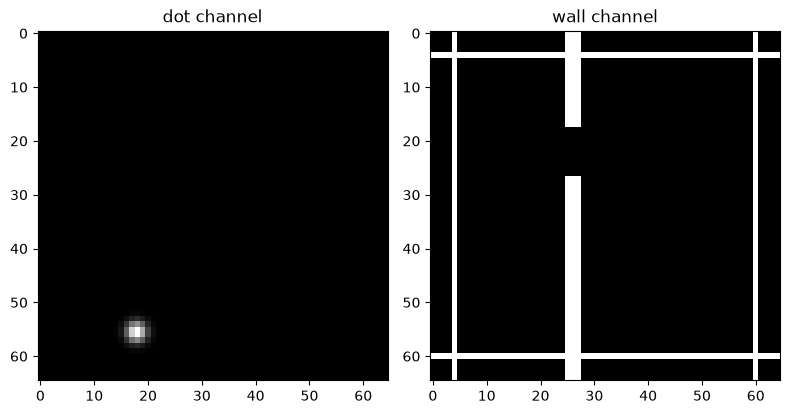

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(states[sample_idx, dot_channel, T], cmap="gray")
axes[0].set_title("dot channel")

axes[1].imshow(states[sample_idx, wall_channel, T], cmap="gray")
axes[1].set_title("wall channel")

plt.tight_layout()
plt.show()


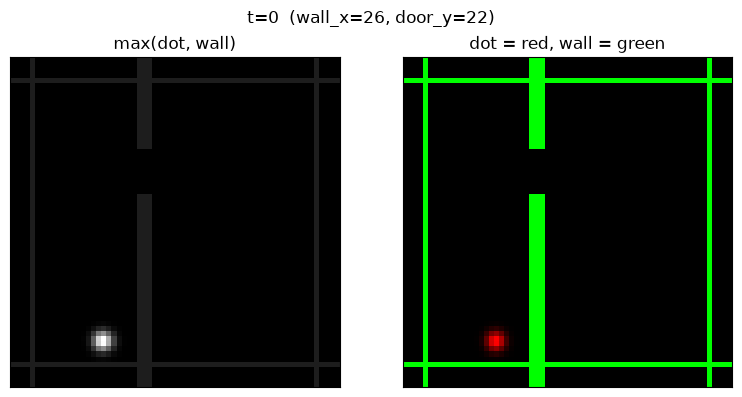

In [76]:
dot = batch.states[sample_idx, dot_channel]    # [T, 65, 65]
wall = batch.states[sample_idx, wall_channel]  # [T, 65, 65]
wx, dy = batch.wall_x[sample_idx].item(), batch.door_y[sample_idx].item()

def to01(x):
    return (x - x.min()) / (x.max() - x.min())

t = 0  # pick any frame
gray = torch.maximum(dot[t], wall[t])
rgb = torch.stack([to01(dot[t]), to01(wall[t]), torch.zeros_like(dot[t])], dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("max(dot, wall)")

axes[1].imshow(rgb)   # dot = red, wall = green
axes[1].set_title("dot = red, wall = green")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"t={t}  (wall_x={wx}, door_y={dy})")
plt.tight_layout()
plt.show()


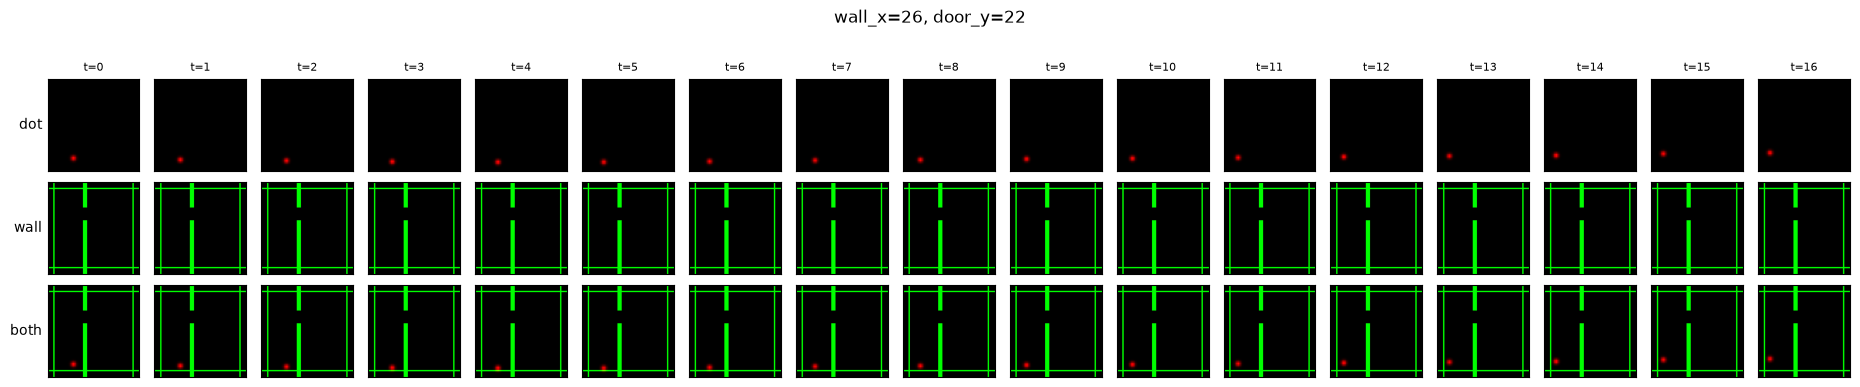

In [77]:
n_frames = dot.shape[0]

def to01(x):
    return (x - x.min()) / (x.max() - x.min())

dot01, wall01 = to01(dot), to01(wall)            # normalize once, over the whole sequence
zeros = torch.zeros_like(dot01)

rows = [
    ("dot",  torch.stack([dot01,  zeros,  zeros], dim=-1)),   # red
    ("wall", torch.stack([zeros,  wall01, zeros], dim=-1)),   # green
    ("both", torch.stack([dot01,  wall01, zeros], dim=-1)),   # red + green
]

fig, axes = plt.subplots(3, n_frames, figsize=(n_frames * 1.1, 3.8))

for r, (name, frames) in enumerate(rows):        # frames: [T, 65, 65, 3]
    for t in range(n_frames):
        ax = axes[r, t]
        ax.imshow(frames[t])
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(f"t={t}", fontsize=8)
    axes[r, 0].set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")

fig.suptitle(f"wall_x={wx}, door_y={dy}", y=1.02)
plt.tight_layout()
plt.show()


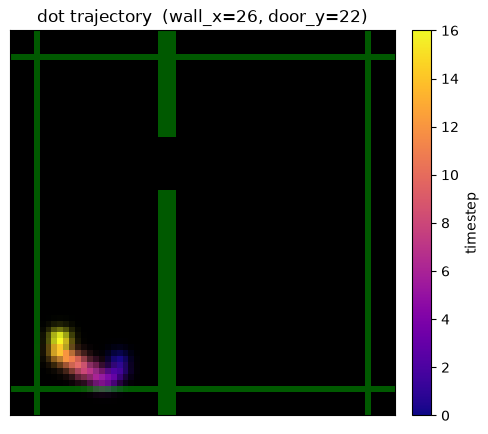

In [78]:
n_frames = dot.shape[0]

def to01(x):
    return (x - x.min()) / (x.max() - x.min())

dot01, wall01 = to01(dot), to01(wall)

cmap = plt.get_cmap("plasma")  # dark purple = early, yellow = late

# dim green wall as the background
img = torch.stack(
    [torch.zeros_like(wall01[0]), wall01[0] * 0.35, torch.zeros_like(wall01[0])],
    dim=-1,
)

# overlay every frame's dot, tinted by its timestep
for t in range(n_frames):
    color = torch.tensor(cmap(t / (n_frames - 1))[:3], dtype=img.dtype)
    img = torch.maximum(img, dot01[t].unsqueeze(-1) * color)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(img.clamp(0, 1))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"dot trajectory  (wall_x={wx}, door_y={dy})")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_frames - 1))
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("timestep")

plt.show()


# locations 

- This is the normalized (x,y) where the center of the dot trajectory is generated. 

In [79]:
print(locations.shape) 

torch.Size([384, 2, 17])


In [80]:
print(locations[sample_idx].shape)
print("=="*50)
print(locations[sample_idx])

torch.Size([2, 17])
tensor([[-0.8537, -0.8544, -0.8904, -0.9390, -0.9935, -1.0398, -1.0877, -1.1500,
         -1.2192, -1.2544, -1.2973, -1.3534, -1.4032, -1.4648, -1.4748, -1.4554,
         -1.4690],
        [ 1.4511,  1.5192,  1.5599,  1.6038,  1.6214,  1.6219,  1.5916,  1.5453,
          1.5230,  1.4874,  1.4623,  1.4279,  1.3913,  1.3568,  1.3289,  1.2553,
          1.2139]])


In [ ]:
locations[sample_idx,: , T] # (x,y) at timestep = 0 

tensor([-0.8537,  1.4511])

In [93]:
states[sample_idx, dot_channel, T].unique()

tensor([-0.0705,  0.0444,  0.1592,  0.2740,  0.3889,  0.5037,  0.6185,  0.7333,
         0.9630,  1.0778,  1.1927,  1.3075,  1.5371,  1.6520,  2.3409,  2.8003,
         3.0299,  3.4892,  3.6041,  3.7189,  4.2930,  4.6375,  5.3265,  5.5561,
         6.7044,  9.8048,  9.9196, 10.1493, 11.8717, 12.3310, 14.5128, 15.0869,
        17.9576, 18.3021, 21.7470, 22.0915, 26.6846, 27.0291])

tensor([[17.8396, 55.4750],
        [17.8277, 56.5753],
        [17.2494, 57.2313],
        [16.4656, 57.9389],
        [15.5886, 58.2242],
        [14.8421, 58.2322],
        [14.0715, 57.7423],
        [13.0685, 56.9957],
        [11.9544, 56.6354],
        [11.3870, 56.0613],
        [10.6960, 55.6567],
        [ 9.7929, 55.1007],
        [ 8.9913, 54.5112],
        [ 7.9996, 53.9546],
        [ 7.8384, 53.5040],
        [ 8.1509, 52.3167],
        [ 7.9315, 51.6484]])


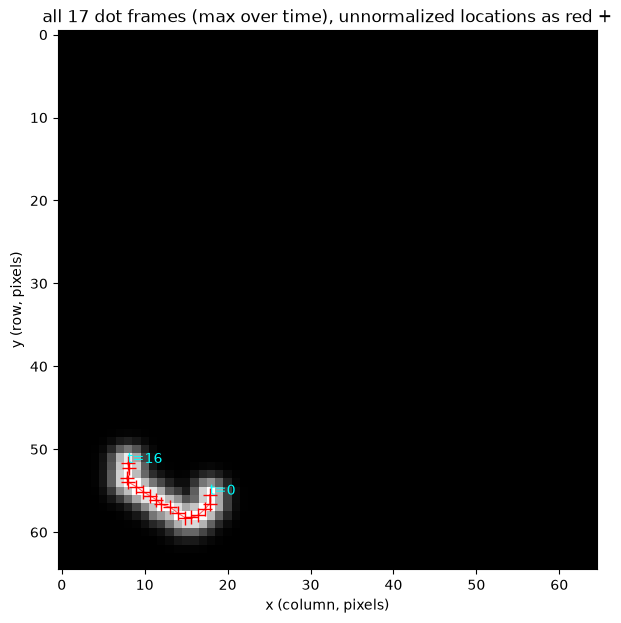

In [99]:
# built-in inverse: Normalizer.unnormalize_location -> loc * std + mean (raw pixels)
# its stats have shape [2] and broadcast against the LAST dim,
# so transpose [2, T] -> [T, 2] before calling
loc_px = loader.dataset.normalizer.unnormalize_location(locations[sample_idx].T)  # [T, 2]
print(loc_px)

# all 17 frames collapsed into one image: max over time of the dot channel
all_frames = states[sample_idx, dot_channel].amax(dim=0)  # [65, 65]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(all_frames, cmap="gray")
ax.plot(loc_px[:, 0], loc_px[:, 1], "r-", linewidth=0.8, alpha=0.6)   # path
ax.plot(loc_px[:, 0], loc_px[:, 1], "r+", markersize=10)              # centers
ax.annotate("t=0", loc_px[0], color="cyan", fontsize=10)
ax.annotate(f"t={len(loc_px)-1}", loc_px[-1], color="cyan", fontsize=10)
ax.set_xlabel("x (column, pixels)")
ax.set_ylabel("y (row, pixels)")
ax.set_title("all 17 dot frames (max over time), unnormalized locations as red +")
plt.show()


# actions 

- actions are not normalized, they stay in raw pixel. 

- What does the (x, y) mean? It's a displacement vector (Δx, Δy): "move Δx pixels horizontally and Δy pixels vertically this timestep.

- ‖(Δx, Δy)‖ ∈ [0.2, 1.8]

In [ ]:
print(actions.shape)    # two channels refer to delta_x and delta_y 
actions[sample_idx] 

torch.Size([384, 2, 17])


tensor([[-0.0119, -0.5783, -0.7838, -0.8770, -0.7465, -0.7707, -1.0030, -1.1141,
         -0.5674, -0.6911, -0.9031, -0.8016, -0.9917, -0.1612,  0.3125, -0.2194,
          0.8076],
        [ 1.1003,  0.6560,  0.7076,  0.2852,  0.0080, -0.4899, -0.7466, -0.3602,
         -0.5741, -0.4047, -0.5560, -0.5894, -0.5567, -0.4506, -1.1873, -0.6683,
         -1.1029]])

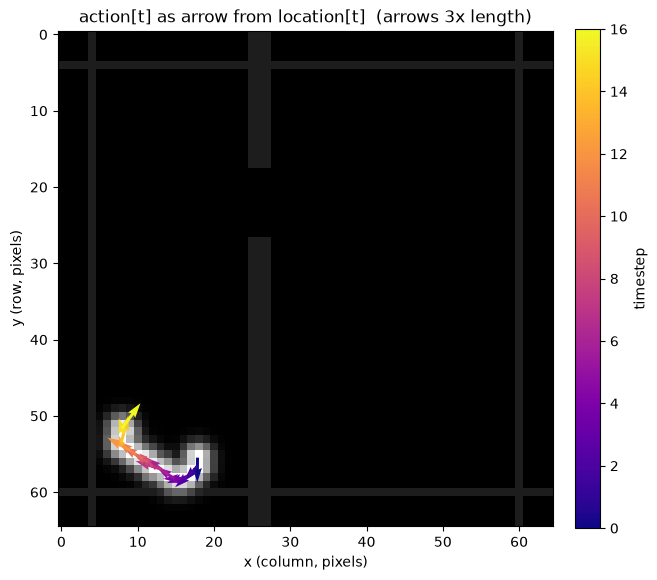

In [100]:
# each action[t] drawn as an arrow starting at location[t]
# actions are already in raw pixels; locations must be unnormalized to match
loc_px = loader.dataset.normalizer.unnormalize_location(locations[sample_idx].T)  # [T, 2]
act_px = actions[sample_idx].T                                                    # [T, 2]
n_frames = act_px.shape[0]

# background: walls + all dot frames collapsed
background = torch.maximum(
    states[sample_idx, dot_channel].amax(dim=0),
    states[sample_idx, wall_channel, 0],
)

ARROW_SCALE = 3  # actions are <= 1.8 px, magnify for visibility

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(background, cmap="gray")

colors = plt.get_cmap("plasma")(np.linspace(0, 1, n_frames))
ax.quiver(
    loc_px[:, 0], loc_px[:, 1],          # arrow start = location[t]
    act_px[:, 0], act_px[:, 1],          # arrow direction = action[t]
    angles="xy", scale_units="xy", scale=1 / ARROW_SCALE,
    color=colors, width=0.006,
)

ax.set_xlabel("x (column, pixels)")
ax.set_ylabel("y (row, pixels)")
ax.set_title(f"action[t] as arrow from location[t]  (arrows {ARROW_SCALE}x length)")

sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(0, n_frames - 1))
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("timestep")

plt.show()


#  wall_x and door_y

- the size of the door comes from the door space (which is 4 in the config)

In [83]:
print(wall_x[sample_idx])   # the vertical line in to create the wall 
print(door_y[sample_idx])   # the gap in y axis 

tensor([26])
tensor([22])


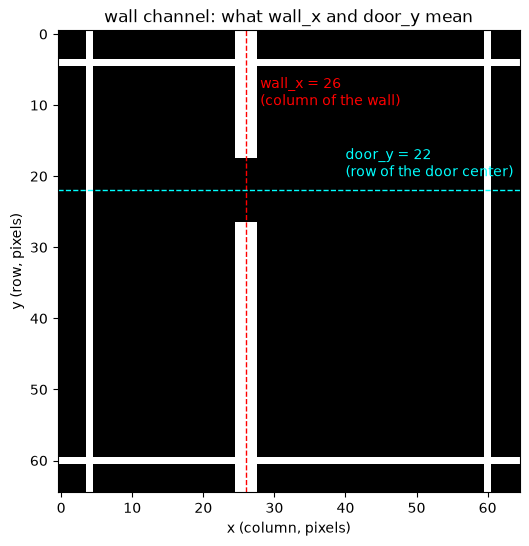

In [101]:
wx = wall_x[sample_idx].item()
dy = door_y[sample_idx].item()

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(states[sample_idx, wall_channel, 0], cmap="gray")

# wall_x = the COLUMN (x) where the vertical wall sits
ax.axvline(wx, color="red", linewidth=1, linestyle="--")
ax.annotate(f"wall_x = {wx}\n(column of the wall)", (wx + 2, 10),
            color="red", fontsize=10)

# door_y = the ROW (y) where the door gap is centered
ax.axhline(dy, color="cyan", linewidth=1, linestyle="--")
ax.annotate(f"door_y = {dy}\n(row of the door center)", (40, dy - 2),
            color="cyan", fontsize=10)

ax.set_xlabel("x (column, pixels)")
ax.set_ylabel("y (row, pixels)")
ax.set_title("wall channel: what wall_x and door_y mean")
plt.show()


# `data_config`

In [84]:
data_config

WallDatasetConfig(size=100000, val_size=10000, batch_size=384, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

In [85]:
print(data_config.batch_size)
print(data_config.size) # train samples  
print(data_config.val_size)

steps_per_epoch = data_config.size // data_config.batch_size
print(steps_per_epoch)

print(data_config.img_size)

print(loader.dataset.normalizer)

384
100000
10000
260
65
